In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt

# Настройка, чтобы графики отображались прямо в Jupyter
%matplotlib inline
random.seed(42)

with open('var_9_dgamma.csv', 'r', encoding='utf-8') as file:
    X = []
    for line in file:
        line = line.strip()
        if line != '':
            X.append(float(line))

n = len(X)


In [2]:
def sample_sum(X):
    s = 0.0
    for x in X:
        s = s + x
    return s

In [3]:
def sample_mean(X):
    s = sample_sum(X)
    n = len(X)
    return s / n

In [4]:
def sample_median(X):
    X_sorted = sorted(X)
    n = len(X_sorted)
    mid = n // 2
    if n % 2 == 1:
        median = X_sorted[mid]
    else:
        median = (X_sorted[mid - 1] + X_sorted[mid]) / 2
    return median

In [5]:
def sample_mode(X):
    freq = {}
    for x in X:
        if x in freq:
            freq[x] = freq[x] + 1
        else:
            freq[x] = 1

    best_value = None
    best_count = 0
    for value in freq:
        count = freq[value]
        if count > best_count:
            best_count = count
            best_value = value
    return best_value

In [6]:
def sample_range(X):
    x_min = X[0]
    x_max = X[0]
    for x in X:
        if x < x_min:
            x_min = x
        if x > x_max:
            x_max = x
    return x_max - x_min

In [7]:
def sample_variance_biased(X):
    mean = sample_mean(X)
    n = len(X)
    s = 0.0
    for x in X:
        s = s + (x - mean) ** 2
    return s / n

In [8]:
def sample_variance_unbiased(X):
    mean = sample_mean(X)
    n = len(X)
    s = 0.0
    for x in X:
        s = s + (x - mean) ** 2
    return s / (n - 1)

In [9]:
def initial_moment(X, k):
    n = len(X)
    s = 0.0
    for x in X:
        s = s + x ** k
    return s / n

In [10]:
def central_moment(X, k):
    mean = sample_mean(X)
    n = len(X)
    s = 0.0
    for x in X:
        s = s + (x - mean) ** k
    return s / n

In [11]:
k = 3

print("n =", n)
print("сумма =", sample_sum(X))
print("среднее =", sample_mean(X))
print("медиана =", sample_median(X))
print("мода =", sample_mode(X))
print("размах =", sample_range(X))
print("смещённая дисперсия =", sample_variance_biased(X))
print("несмещённая дисперсия =", sample_variance_unbiased(X))
print("начальный момент", k, "-го порядка =", initial_moment(X, k))
print("центральный момент", k, "-го порядка =", central_moment(X, k))

n = 300
сумма = 251.787422
среднее = 0.8392914066666667
медиана = 3.9813270000000003
мода = -4.223468
размах = 28.723799999999997
смещённая дисперсия = 56.99760139626665
несмещённая дисперсия = 57.188228825685606
начальный момент 3 -го порядка = 104.33700333162143
центральный момент 3 -го порядка = -39.76699314045393


In [12]:
def ecdf(sample, x):
    n = len(sample)
    count = 0
    for xi in sample:
        if xi <= x:
            count = count + 1
    return count / n

In [13]:
def ecdf_curve(sample):
    sample_sorted = sorted(sample)
    x_min = sample_sorted[0]
    x_max = sample_sorted[-1]
    margin = (x_max - x_min) * 0.05

    x_values = []
    x_values.append(x_min - margin)
    for value in sample_sorted:
        x_values.append(value)
    x_values.append(x_max + margin)

    y_values = []
    for x in x_values:
        y_values.append(ecdf(sample, x))

    return x_values, y_values

In [14]:
import random

random.seed(42)

sample_10 = random.sample(X, 10)
sample_100 = random.sample(X, 100)
sample_200 = random.sample(X, 200)

In [15]:
import math

def dgamma_pdf(t, alpha, beta, loc):
    d = abs(t - loc)
    f = (beta ** alpha) / (2 * math.gamma(alpha)) * (d ** (alpha - 1)) * math.exp(-beta * d)
    return f

In [16]:
def dgamma_cdf_grid(alpha, beta, loc, x_left, x_right, dx):
    x_grid = []
    F_grid = []

    x = x_left
    F = 0.0
    while x <= x_right:
        f = dgamma_pdf(x, alpha, beta, loc)
        F = F + f * dx
        x_grid.append(x)
        F_grid.append(F)
        x = x + dx

    return x_grid, F_grid

In [17]:
alpha_theory = 6.35
beta_theory = 1.0
loc_theory = 1.15

x_left = min(X) - 15
x_right = max(X) + 15

x_theory, y_theory = dgamma_cdf_grid(alpha_theory, beta_theory, loc_theory, x_left, x_right, 0.01)

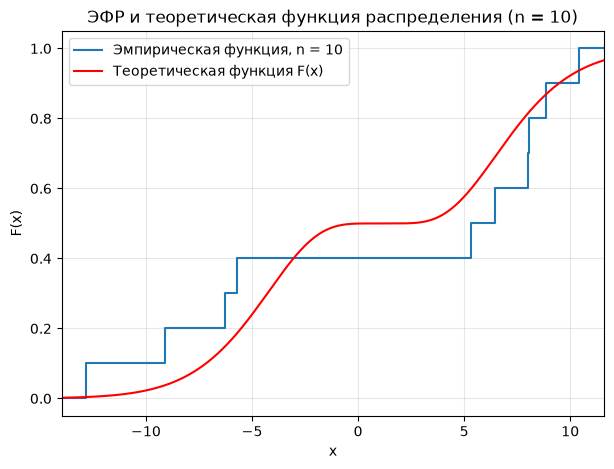

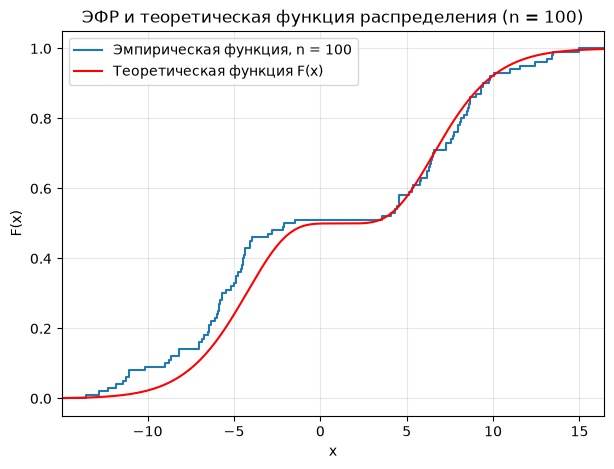

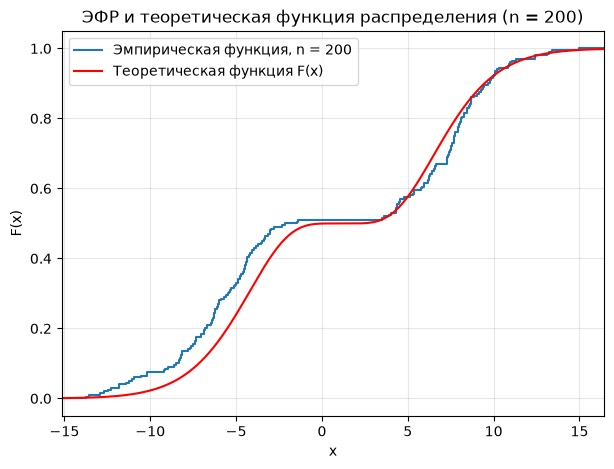

In [18]:
import matplotlib.pyplot as plt

subsamples = [(10, sample_10), (100, sample_100), (200, sample_200)]

for size, sample in subsamples:
    x_values, y_values = ecdf_curve(sample)

    plt.figure(figsize=(7, 5))
    plt.plot(x_values, y_values, drawstyle='steps-post', label='Эмпирическая функция, n = ' + str(size))
    plt.plot(x_theory, y_theory, color='red', label='Теоретическая функция F(x)')
    plt.xlim(x_values[0], x_values[-1])
    plt.title('ЭФР и теоретическая функция распределения (n = ' + str(size) + ')')
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [19]:
def sturges_k(n):
    k = 1
    power = 2
    while power < n:
        k = k + 1
        power = power * 2
    return k

In [20]:
def build_histogram(sample, k=None):
    n = len(sample)

    if k is None:
        k = sturges_k(n)

    x_min = sample[0]
    x_max = sample[0]
    for x in sample:
        if x < x_min:
            x_min = x
        if x > x_max:
            x_max = x

    h = (x_max - x_min) / k

    counts = [0] * k
    for x in sample:
        idx = int((x - x_min) / h)
        if idx == k:            # правая граница последнего интервала
            idx = k - 1
        counts[idx] = counts[idx] + 1

    edges = []
    for i in range(k + 1):
        edges.append(x_min + i * h)

    heights = []
    for count in counts:
        height = count / (n * h)
        heights.append(height)

    return edges, heights

In [21]:
random.seed(7)

sample_10_hist = random.sample(X, 10)
sample_100_hist = random.sample(X, 100)
sample_200_hist = random.sample(X, 200)

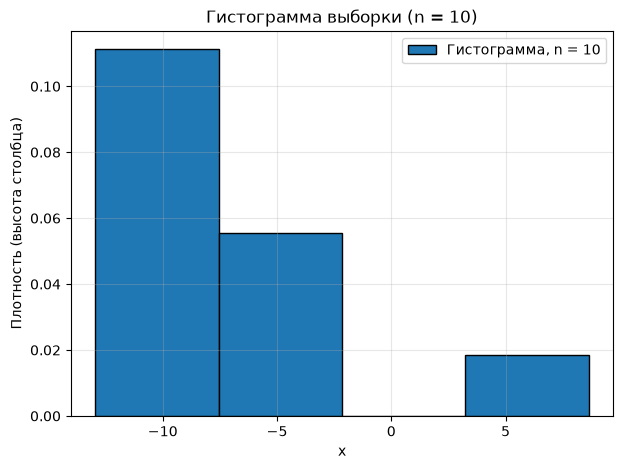

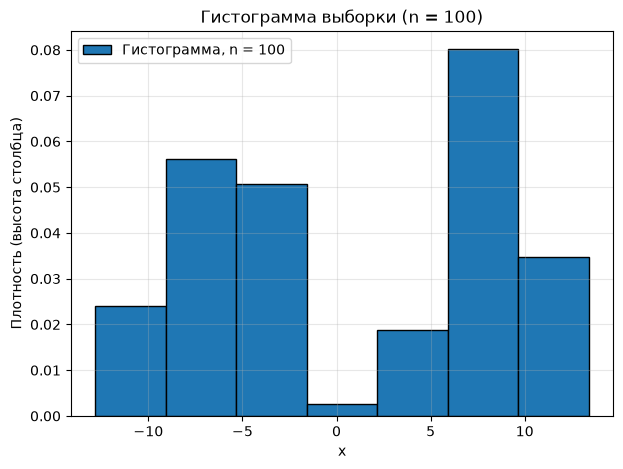

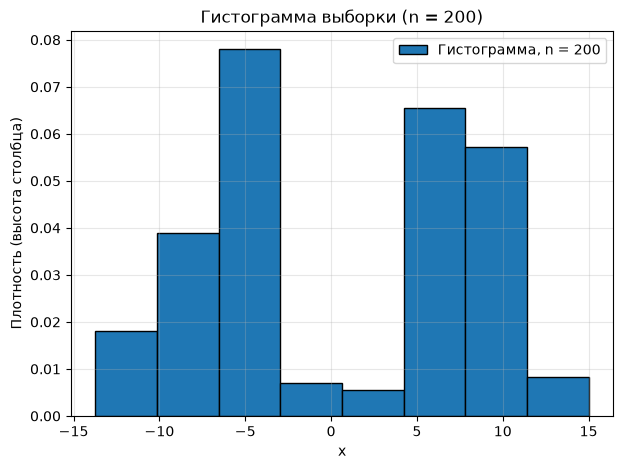

In [22]:
subsamples_hist = [(10, sample_10_hist), (100, sample_100_hist), (200, sample_200_hist)]

for size, sample in subsamples_hist:
    edges, heights = build_histogram(sample)
    h = edges[1] - edges[0]

    plt.figure(figsize=(7, 5))
    plt.bar(edges[:-1], heights, width=h, align='edge', edgecolor='black', label='Гистограмма, n = ' + str(size))
    plt.title('Гистограмма выборки (n = ' + str(size) + ')')
    plt.xlabel('x')
    plt.ylabel('Плотность (высота столбца)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()